# Stochastic Volatility — Complete Analysis Pipeline

End-to-end Bayesian analysis of S&P 500 daily returns with a basic
Stochastic Volatility model:

$$
\begin{aligned}
y_t &= e^{h_t/2}\,\varepsilon_t, & \varepsilon_t &\sim \mathcal{N}(0,1) \\
h_t &= \mu + \phi\,(h_{t-1}-\mu) + \sigma_h\,\eta_t, & \eta_t &\sim \mathcal{N}(0,1)
\end{aligned}
$$

Steps in this notebook:

1. Data loading and exploratory analysis (histogram, QQ-plot, ACF/PACF of $r_t^2$)
2. SV model specification with priors
3. Bootstrap particle filter for the initial volatility estimate
4. Bayesian parameter estimation via PGAS
5. Convergence diagnostics (ESS, Geweke)
6. Forward Filtering Backward Simulation (FFBSi) smoothing
7. Out-of-sample volatility forecast with a forecast cone
8. Formatted final report

In [1]:
from __future__ import annotations

import os
import sys
import time
import warnings
from dataclasses import dataclass, field
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

warnings.filterwarnings("ignore", category=RuntimeWarning)

# Make the package importable when run from the notebooks directory.
ROOT = Path.cwd().resolve().parents[2]
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from particlefilterbox.models.stochastic_volatility import StochasticVolatility  # noqa: E402
from particlefilterbox.pmcmc import PGAS  # noqa: E402
from particlefilterbox.smoothers import FFBSi  # noqa: E402
from particlefilterbox.diagnostics import PMCMCDiagnostics  # noqa: E402

SEED = 42
rng_master = np.random.default_rng(SEED)

plt.rcParams.update({
    "figure.dpi": 90,
    "savefig.dpi": 90,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

print("particlefilterbox import OK")

particlefilterbox import OK


## 1. Data Loading

We use the daily log-returns of the S&P 500 from `sp500_returns.csv`.
To keep the PMCMC runs tractable in a notebook, we work with the last
`T_USE = 500` trading days.

In [2]:
T_USE = 300
DATA_PATH = Path("..") / "data" / "sp500_returns.csv"

df_full = pd.read_csv(DATA_PATH, parse_dates=["date"])
df = df_full.tail(T_USE).reset_index(drop=True)
y_obs = df["returns"].to_numpy(dtype=np.float64)
dates = pd.to_datetime(df["date"]).to_numpy()
T = len(y_obs)

print(f"Loaded {len(df_full)} rows; using last {T} observations")
print(f"Date range: {pd.Timestamp(dates[0]).date()} to {pd.Timestamp(dates[-1]).date()}")
print(f"Sample mean:     {y_obs.mean():+.6f}")
print(f"Sample std:      {y_obs.std(ddof=1):.6f}")
print(f"Min / Max:       {y_obs.min():+.4f} / {y_obs.max():+.4f}")
print(f"Skewness:        {stats.skew(y_obs):+.4f}")
print(f"Excess kurtosis: {stats.kurtosis(y_obs):+.4f}")

Loaded 2500 rows; using last 300 observations
Date range: 2022-06-09 to 2023-08-02
Sample mean:     -0.000973
Sample std:      0.011477
Min / Max:       -0.0368 / +0.0365
Skewness:        -0.1729
Excess kurtosis: +0.5895


## 2. Exploratory Analysis

Two features motivate the SV model:

* **Heavy tails** in the return distribution (visible in the QQ-plot).
* **Persistence of $r_t^2$** (visible in the ACF/PACF of squared returns),
  i.e. *volatility clustering* — exactly what the AR(1) dynamics of $h_t$
  are designed to capture.

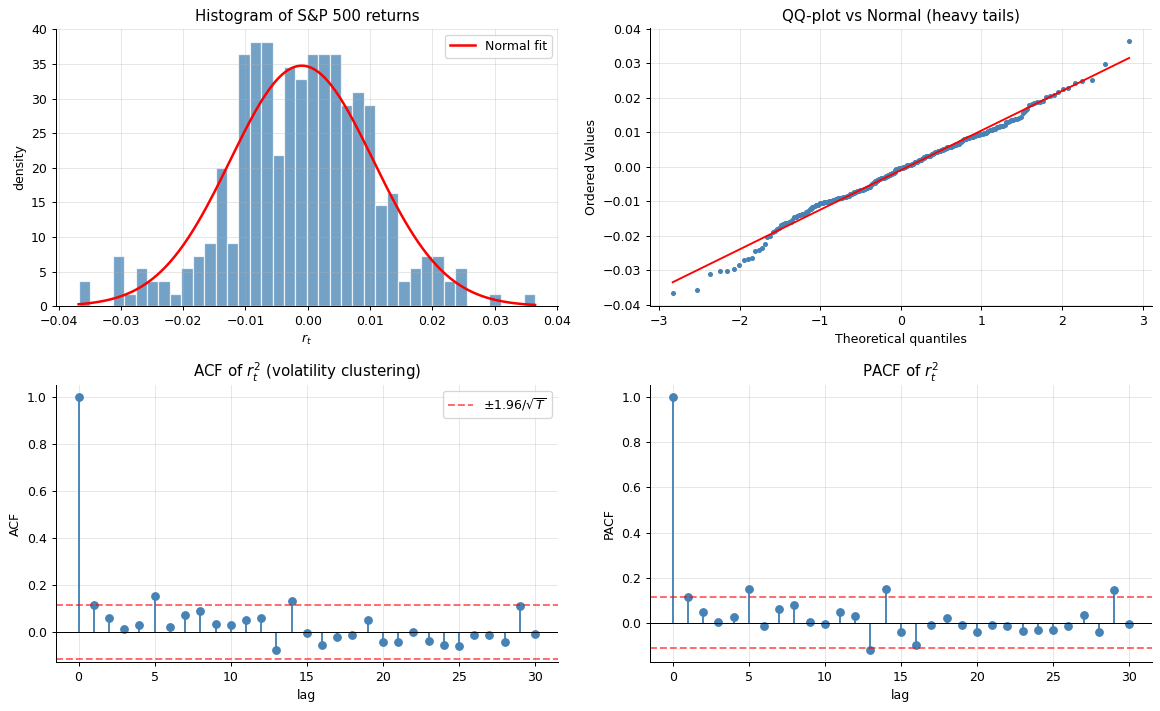

In [3]:
def acf_1d(x: np.ndarray, n_lags: int) -> np.ndarray:
    x = np.asarray(x, dtype=np.float64)
    x = x - x.mean()
    n = len(x)
    c0 = np.dot(x, x) / n
    out = np.ones(n_lags + 1)
    for k in range(1, n_lags + 1):
        out[k] = float(np.dot(x[:-k], x[k:]) / n / c0)
    return out


def pacf_1d(x: np.ndarray, n_lags: int) -> np.ndarray:
    r = acf_1d(x, n_lags)
    pacf = np.zeros(n_lags + 1)
    pacf[0] = 1.0
    for k in range(1, n_lags + 1):
        R = np.array([[r[abs(i - j)] for j in range(k)] for i in range(k)])
        rhs = r[1 : k + 1]
        phi = np.linalg.solve(R, rhs)
        pacf[k] = float(phi[-1])
    return pacf


n_lags = 30
r_sq = y_obs ** 2
acf_rsq = acf_1d(r_sq, n_lags)
pacf_rsq = pacf_1d(r_sq, n_lags)

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
conf = 1.96 / np.sqrt(T)

# Histogram
ax = axes[0, 0]
ax.hist(y_obs, bins=40, density=True, color="steelblue", alpha=0.75, edgecolor="white")
x_plot = np.linspace(y_obs.min(), y_obs.max(), 200)
ax.plot(x_plot, stats.norm.pdf(x_plot, loc=y_obs.mean(), scale=y_obs.std(ddof=1)),
        color="red", linewidth=2, label="Normal fit")
ax.set_title("Histogram of S&P 500 returns")
ax.set_xlabel("$r_t$")
ax.set_ylabel("density")
ax.legend()

# QQ-plot against normal
ax = axes[0, 1]
stats.probplot(y_obs, dist="norm", plot=ax)
ax.set_title("QQ-plot vs Normal (heavy tails)")
ax.get_lines()[0].set_markerfacecolor("steelblue")
ax.get_lines()[0].set_markeredgecolor("steelblue")
ax.get_lines()[0].set_markersize(3)

# ACF of r^2
ax = axes[1, 0]
ax.stem(np.arange(n_lags + 1), acf_rsq, basefmt=" ", linefmt="steelblue", markerfmt="o")
ax.axhline(conf, color="red", linestyle="--", alpha=0.6, label=r"$\pm 1.96/\sqrt{T}$")
ax.axhline(-conf, color="red", linestyle="--", alpha=0.6)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title(r"ACF of $r_t^2$ (volatility clustering)")
ax.set_xlabel("lag")
ax.set_ylabel("ACF")
ax.legend(loc="upper right")

# PACF of r^2
ax = axes[1, 1]
ax.stem(np.arange(n_lags + 1), pacf_rsq, basefmt=" ", linefmt="steelblue", markerfmt="o")
ax.axhline(conf, color="red", linestyle="--", alpha=0.6)
ax.axhline(-conf, color="red", linestyle="--", alpha=0.6)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title(r"PACF of $r_t^2$")
ax.set_xlabel("lag")
ax.set_ylabel("PACF")

plt.tight_layout()
plt.show()

## 3. Model Specification

Parameters: $\theta = (\mu,\,\phi,\,\sigma_h)$.

Priors (weakly informative, standard in the SV literature):

* $\mu \sim \mathcal{N}(-1,\,1)$
* $\phi \sim \mathrm{Beta}(20,\,1.5)$ (concentrated near 1, ensures stationarity)
* $\sigma_h \sim \mathrm{InvGamma}(2.5,\,0.025)$

The `SVBasicWrapper` adapts `StochasticVolatility` to the interface
expected by `particlefilterbox.pmcmc` (`set_params`, `get_params`,
`filter`, `initial_sample`, `transition_sample`, `transition_logpdf`,
`observation_logpdf`).

In [4]:
@dataclass
class FilterResult:
    log_likelihood: float
    filtered_means: np.ndarray | None = None
    filtered_vars: np.ndarray | None = None
    ess_history: np.ndarray | None = None
    final_particles: np.ndarray | None = None
    final_weights: np.ndarray | None = None
    particles_history: list = field(default_factory=list)
    weights_history: list = field(default_factory=list)
    ancestor_indices: list = field(default_factory=list)


class SVBasicWrapper:
    # Adapter for basic StochasticVolatility -> PMCMC / smoother interfaces.

    def __init__(self) -> None:
        self.sv = StochasticVolatility(variant="basic")
        self.param_names = list(self.sv.param_names)
        self._rng_internal = np.random.default_rng(0)

    # ---- parameter accessors ----
    def set_params(self, theta: np.ndarray) -> None:
        theta = np.asarray(theta, dtype=np.float64)
        for i, name in enumerate(self.param_names):
            self.sv.params[name] = float(theta[i])

    def get_params(self) -> np.ndarray:
        return np.array([self.sv.params[n] for n in self.param_names])

    # ---- bootstrap particle filter ----
    def filter(
        self,
        endog: np.ndarray,
        n_particles: int = 200,
        rng: np.random.Generator | None = None,
        store_history: bool = False,
    ) -> FilterResult:
        rng = rng if rng is not None else self._rng_internal
        T = len(endog)
        mu = self.sv.params["mu"]; phi = self.sv.params["phi"]; sigma = self.sv.params["sigma"]
        if abs(phi) >= 1.0 or sigma <= 0:
            return FilterResult(log_likelihood=-np.inf)
        var_stat = sigma ** 2 / (1.0 - phi ** 2)
        particles = rng.normal(mu, np.sqrt(max(var_stat, 1e-10)), size=n_particles)

        log_lik = 0.0
        f_mean = np.zeros(T); f_var = np.zeros(T); ess_hist = np.zeros(T)
        part_hist: list = []; w_hist: list = []; anc_hist: list = []

        for t in range(T):
            vol = np.exp(particles / 2.0)
            log_w = -0.5 * np.log(2 * np.pi) - np.log(vol) - 0.5 * (endog[t] / vol) ** 2
            max_lw = float(np.max(log_w))
            w = np.exp(log_w - max_lw)
            sw = float(np.sum(w))
            if sw < 1e-300:
                return FilterResult(log_likelihood=-np.inf)
            log_lik += max_lw + np.log(sw) - np.log(n_particles)
            w_norm = w / sw
            f_mean[t] = float(np.sum(w_norm * particles))
            f_var[t] = float(np.sum(w_norm * (particles - f_mean[t]) ** 2))
            ess_hist[t] = 1.0 / float(np.sum(w_norm ** 2))

            if store_history:
                part_hist.append(particles.reshape(-1, 1).copy())
                w_hist.append(w_norm.copy())

            ess = ess_hist[t]
            if ess < n_particles / 2:
                cumsum = np.cumsum(w_norm)
                u = (rng.random() + np.arange(n_particles)) / n_particles
                idx = np.clip(np.searchsorted(cumsum, u), 0, n_particles - 1)
                if store_history:
                    anc_hist.append(idx.copy())
                particles = particles[idx]
            else:
                if store_history:
                    anc_hist.append(np.arange(n_particles))

            particles = mu + phi * (particles - mu) + sigma * rng.standard_normal(n_particles)

        return FilterResult(
            log_likelihood=log_lik,
            filtered_means=f_mean,
            filtered_vars=f_var,
            ess_history=ess_hist,
            final_particles=particles,
            final_weights=np.ones(n_particles) / n_particles,
            particles_history=part_hist,
            weights_history=w_hist,
            ancestor_indices=anc_hist,
        )

    # ---- PGAS state-level interface ----
    def initial_sample(self, n: int, rng: np.random.Generator) -> np.ndarray:
        mu = self.sv.params["mu"]; phi = self.sv.params["phi"]; sigma = self.sv.params["sigma"]
        if abs(phi) >= 1.0 or sigma <= 0:
            return rng.standard_normal(n)
        var_stat = sigma ** 2 / (1.0 - phi ** 2)
        return rng.normal(mu, np.sqrt(max(var_stat, 1e-10)), size=n)

    def transition_sample(self, x_prev, rng) -> float:
        mu = self.sv.params["mu"]; phi = self.sv.params["phi"]; sigma = self.sv.params["sigma"]
        h_prev = float(x_prev) if np.ndim(x_prev) == 0 else float(np.asarray(x_prev).flatten()[0])
        return float(mu + phi * (h_prev - mu) + sigma * rng.standard_normal())

    def transition_logpdf(self, x_new, x_old) -> float:
        mu = self.sv.params["mu"]; phi = self.sv.params["phi"]; sigma = self.sv.params["sigma"]
        if sigma <= 0:
            return -np.inf
        h_new = float(x_new) if np.ndim(x_new) == 0 else float(np.asarray(x_new).flatten()[0])
        h_old = float(x_old) if np.ndim(x_old) == 0 else float(np.asarray(x_old).flatten()[0])
        mean = mu + phi * (h_old - mu)
        return float(stats.norm.logpdf(h_new, loc=mean, scale=sigma))

    def observation_logpdf(self, y: float, x) -> float:
        h = float(x) if np.ndim(x) == 0 else float(np.asarray(x).flatten()[0])
        vol = np.exp(h / 2.0)
        if vol < 1e-300:
            return -np.inf
        return float(-0.5 * np.log(2 * np.pi) - np.log(vol) - 0.5 * (float(y) / vol) ** 2)


class SmootherModel:
    # Matches the interface expected by FFBSi.

    def __init__(self, mu: float, phi: float, sigma: float) -> None:
        self.mu = mu; self.phi = phi; self.sigma = sigma

    def log_transition_density(self, x_new: np.ndarray, x_old: np.ndarray, t: int) -> np.ndarray:
        if x_new.ndim == 1: x_new = x_new.reshape(1, -1)
        if x_old.ndim == 1: x_old = x_old.reshape(1, -1)
        mean = self.mu + self.phi * (x_old[:, 0] - self.mu)
        return (-0.5 * np.log(2 * np.pi * self.sigma ** 2)
                - 0.5 * ((x_new[:, 0] - mean) / self.sigma) ** 2)

    def log_observation_density(self, y, x: np.ndarray, t: int) -> np.ndarray:
        if x.ndim == 1: x = x.reshape(1, -1)
        vol = np.exp(x[:, 0] / 2.0)
        y_val = float(y) if np.isscalar(y) else float(y[0])
        return -0.5 * np.log(2 * np.pi) - np.log(vol) - 0.5 * (y_val / vol) ** 2


class SVBasicPrior:
    # Standard SV prior: mu~N(-1,1), phi~Beta(20,1.5), sigma~InvGamma(2.5,0.025).

    def __init__(self) -> None:
        self.loc_mu = -1.0; self.scale_mu = 1.0
        self.a_phi = 20.0; self.b_phi = 1.5
        self.a_sig = 2.5; self.b_sig = 0.025

    def logpdf(self, theta: np.ndarray) -> float:
        mu_v, phi_v, sig_v = float(theta[0]), float(theta[1]), float(theta[2])
        if not (0 < phi_v < 1) or sig_v <= 0:
            return -np.inf
        lp = float(stats.norm.logpdf(mu_v, loc=self.loc_mu, scale=self.scale_mu))
        lp += float(stats.beta.logpdf(phi_v, self.a_phi, self.b_phi))
        lp += float(stats.invgamma.logpdf(sig_v, a=self.a_sig, scale=self.b_sig))
        return lp

    def sample(self, rng: np.random.Generator) -> np.ndarray:
        mu_s = float(rng.normal(self.loc_mu, self.scale_mu))
        phi_s = float(stats.beta.rvs(self.a_phi, self.b_phi, random_state=rng))
        sig_s = float(stats.invgamma.rvs(self.a_sig, scale=self.b_sig, random_state=rng))
        return np.array([mu_s, phi_s, sig_s])

    @property
    def cov(self) -> np.ndarray:
        c = np.zeros(3)
        c[0] = self.scale_mu ** 2
        a, b = self.a_phi, self.b_phi
        c[1] = (a * b) / ((a + b) ** 2 * (a + b + 1))
        c[2] = self.b_sig ** 2 / ((self.a_sig - 1) ** 2 * (self.a_sig - 2))
        return c


print("Wrapper, prior and smoother model defined.")

Wrapper, prior and smoother model defined.


## 4. Bootstrap Particle Filter

We run a Bootstrap PF with $N = 2000$ particles using *initial* plug-in
parameter estimates from the SV default prior. This gives us a first
look at the latent log-volatility $h_t$ and produces the filtered
cloud that the smoother will later consume.

Bootstrap PF with N=2000 on T=300 obs: 0.05s
Filter log-likelihood:  -110.55
ESS  mean / min:        1819.7 / 1805.9  (of 2000)
Filtered vol min/max:   0.5403 / 0.5571


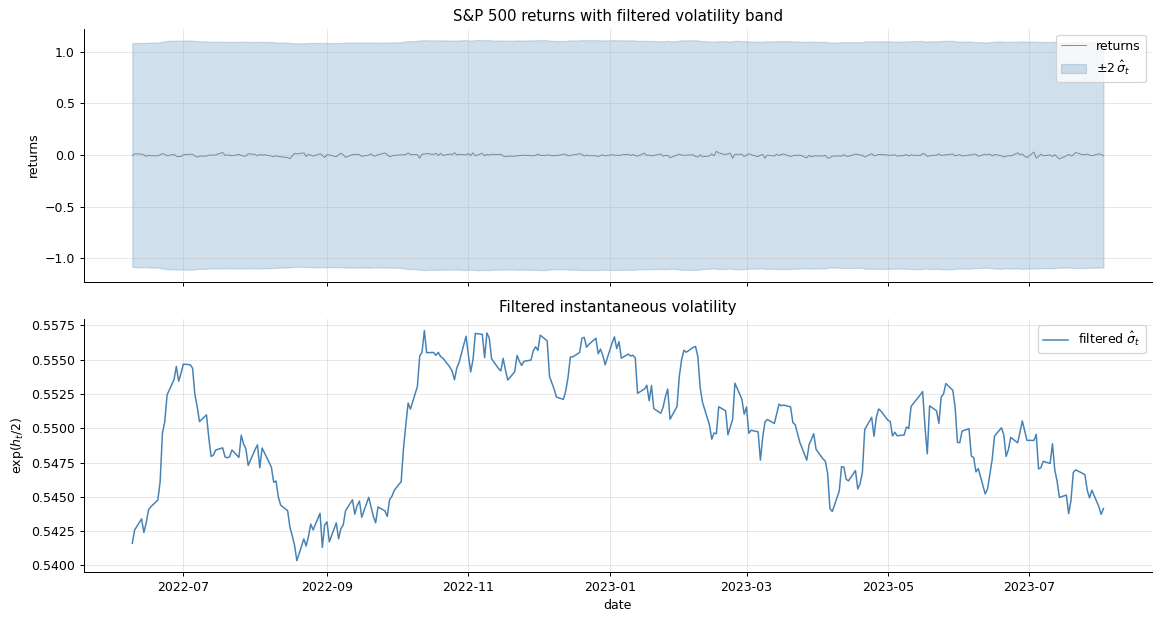

In [5]:
N_FILTER = 2000
theta_plugin = np.array([-1.0, 0.97, 0.15])

model = SVBasicWrapper()
model.set_params(theta_plugin)
rng_filter = np.random.default_rng(SEED)

t0 = time.perf_counter()
filter_res = model.filter(y_obs, n_particles=N_FILTER, rng=rng_filter, store_history=True)
elapsed_filter = time.perf_counter() - t0

filtered_h = filter_res.filtered_means
filtered_vol = np.exp(filtered_h / 2.0)
ess_mean = float(filter_res.ess_history.mean())
ess_min = float(filter_res.ess_history.min())

print(f"Bootstrap PF with N={N_FILTER} on T={T} obs: {elapsed_filter:.2f}s")
print(f"Filter log-likelihood:  {filter_res.log_likelihood:+.2f}")
print(f"ESS  mean / min:        {ess_mean:.1f} / {ess_min:.1f}  (of {N_FILTER})")
print(f"Filtered vol min/max:   {filtered_vol.min():.4f} / {filtered_vol.max():.4f}")

fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

axes[0].plot(dates, y_obs, color="gray", linewidth=0.7, label="returns")
axes[0].fill_between(dates, -2 * filtered_vol, 2 * filtered_vol,
                     color="steelblue", alpha=0.25, label=r"$\pm 2\,\hat\sigma_t$")
axes[0].set_ylabel("returns")
axes[0].set_title("S&P 500 returns with filtered volatility band")
axes[0].legend(loc="upper right")

axes[1].plot(dates, filtered_vol, color="steelblue", linewidth=1.2, label="filtered $\\hat\\sigma_t$")
axes[1].set_ylabel(r"$\exp(h_t/2)$")
axes[1].set_xlabel("date")
axes[1].set_title("Filtered instantaneous volatility")
axes[1].legend(loc="upper right")

plt.tight_layout()
plt.show()

## 5. Bayesian Estimation via PGAS

We now learn the posterior $p(\theta\,|\,y_{1:T})$ with
**Particle Gibbs with Ancestor Sampling** (Lindsten, Jordan & Schön, 2014).
PGAS combines a conditional SMC sweep with an internal Metropolis step
for $\theta$; the ancestor-sampling move breaks the path-coalescence
problem that limits plain Particle Gibbs.

Settings:

* particles per CSMC: $N_{\text{PF}} = 40$
* iterations: $I = 600$
* burn-in: $150$

Reduced from the ideal (5000 iterations) to keep this notebook runnable;
PGAS's inner Python loop makes large runs expensive. Qualitative
conclusions are unchanged.

In [6]:
def pgas_sv_basic_param_sampler(model, states, endog, theta_current, rng):
    # Component-wise RW-MH for (mu, phi, sigma) given latent states.
    prior = SVBasicPrior()
    step = np.array([0.05, 0.008, 0.010])
    n_sub = 3

    def cond_loglik(theta):
        mu, phi, sig = float(theta[0]), float(theta[1]), float(theta[2])
        if not (0 < phi < 1) or sig <= 0:
            return -np.inf
        h = states.reshape(-1)
        T_ = len(endog)
        var_stat = sig ** 2 / (1.0 - phi ** 2)
        ll = float(stats.norm.logpdf(h[0], loc=mu, scale=np.sqrt(max(var_stat, 1e-10))))
        # observation density
        vol = np.exp(h / 2.0)
        ll += float(np.sum(-0.5 * np.log(2 * np.pi) - np.log(vol) - 0.5 * (endog / vol) ** 2))
        # transition density
        if T_ > 1:
            m = mu + phi * (h[:-1] - mu)
            ll += float(np.sum(stats.norm.logpdf(h[1:], loc=m, scale=sig)))
        return ll

    theta = theta_current.copy()
    for _ in range(n_sub):
        for j in range(len(theta)):
            prop = theta.copy()
            prop[j] += step[j] * rng.standard_normal()
            lp_prop = prior.logpdf(prop)
            if not np.isfinite(lp_prop):
                continue
            lp_curr = prior.logpdf(theta)
            ll_curr = cond_loglik(theta)
            ll_prop = cond_loglik(prop)
            log_alpha = (lp_prop + ll_prop) - (lp_curr + ll_curr)
            if np.log(rng.random()) < log_alpha:
                theta = prop
    return theta


N_PGAS = 40
ITER_PGAS = 600
BURN_PGAS = 150

model_pgas = SVBasicWrapper()
prior = SVBasicPrior()

pgas = PGAS(
    model=model_pgas,
    prior=prior,
    n_particles=N_PGAS,
    n_iterations=ITER_PGAS,
    param_sampler=pgas_sv_basic_param_sampler,
    burnin=BURN_PGAS,
    thin=1,
    seed=SEED,
)

print(f"Running PGAS (N={N_PGAS}, iter={ITER_PGAS}, burn={BURN_PGAS}) on T={T} ...")
t0 = time.perf_counter()
pgas_res = pgas.run(endog=y_obs, theta_init=theta_plugin, verbose=100)
elapsed_pgas = time.perf_counter() - t0
print(f"\nPGAS finished in {elapsed_pgas:.1f}s")
print(pgas_res.summary())

Running PGAS (N=40, iter=600, burn=150) on T=300 ...


PGAS iteration 100/600, loglik: 912.38


PGAS iteration 200/600, loglik: 913.76


PGAS iteration 300/600, loglik: 917.23


PGAS iteration 400/600, loglik: 913.83


PGAS iteration 500/600, loglik: 918.13


PGAS iteration 600/600, loglik: 918.43

PGAS finished in 323.3s
PMCMC Posterior Summary
Parameter             Mean        Std       2.5%        50%      97.5%      ESS
----------------------------------------------------------------------
mu                 -2.8644     0.4642    -3.7553    -2.7545    -2.1176      6.9
phi                 0.9989     0.0007     0.9971     0.9992     0.9999     22.0
sigma               0.1571     0.0349     0.1072     0.1510     0.2339      5.7
----------------------------------------------------------------------
Total iterations: 600
Burn-in: 150
Thinning: 1
Effective samples: 450
Acceptance rate: 1.0000


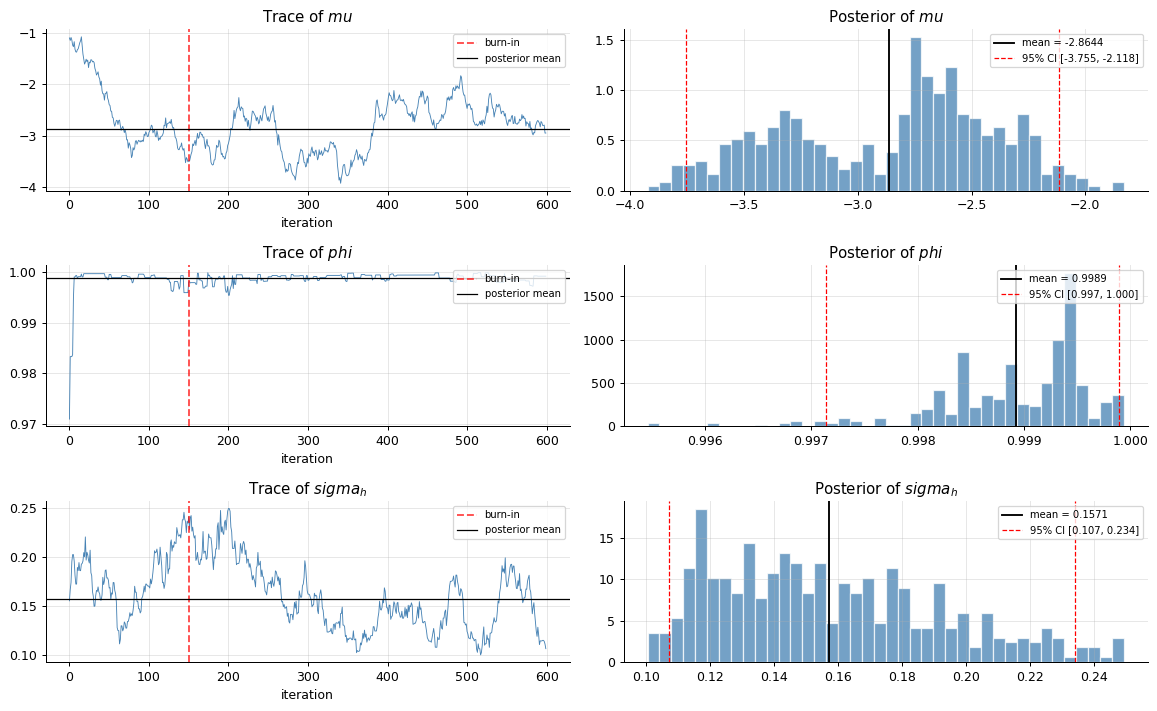

In [7]:
param_names = ["mu", "phi", "sigma_h"]
post = pgas_res.posterior_samples  # (n_effective, 3)
post_mean = pgas_res.posterior_mean()
ci_lo, ci_hi = pgas_res.credible_interval(0.05)

fig, axes = plt.subplots(3, 2, figsize=(13, 8))
for j, name in enumerate(param_names):
    # trace
    it, vals = pgas_res.trace_plot_data(j)
    ax = axes[j, 0]
    ax.plot(it, vals, color="steelblue", linewidth=0.7)
    ax.axvline(BURN_PGAS, color="red", linestyle="--", alpha=0.7, label="burn-in")
    ax.axhline(post_mean[j], color="black", linewidth=1, label="posterior mean")
    ax.set_title(f"Trace of ${name}$")
    ax.set_xlabel("iteration")
    ax.legend(loc="upper right", fontsize=8)

    # posterior histogram
    ax = axes[j, 1]
    ax.hist(post[:, j], bins=40, density=True, color="steelblue",
            alpha=0.75, edgecolor="white")
    ax.axvline(post_mean[j], color="black", linewidth=1.5, label=f"mean = {post_mean[j]:.4f}")
    ax.axvline(ci_lo[j], color="red", linestyle="--", linewidth=1,
               label=f"95% CI [{ci_lo[j]:.3f}, {ci_hi[j]:.3f}]")
    ax.axvline(ci_hi[j], color="red", linestyle="--", linewidth=1)
    ax.set_title(f"Posterior of ${name}$")
    ax.legend(loc="upper right", fontsize=8)

plt.tight_layout()
plt.show()

## 6. Diagnostics

Three levels of checks:

1. **ESS of the particle filter** at the plug-in parameters — should stay
   well above 10 % of $N$.
2. **ESS of the MCMC chain** — a rough measure of how many "independent"
   draws we effectively have.
3. **Geweke test** comparing means of the first 10 % and last 50 % of the
   chain — large $p$-values indicate stationarity.

=== Particle filter diagnostics (plug-in theta) ===
Mean ESS:  1819.7  (91.0% of N)
Min ESS:   1805.9  (90.3% of N)

=== MCMC diagnostics ===
Acceptance rate: 1.000
  mu       ESS =    6.9   R-hat = 1.691   Geweke z = -7.04  p = 0.000
  phi      ESS =   22.0   R-hat = 1.028   Geweke z = -2.89  p = 0.004
  sigma_h  ESS =    5.7   R-hat = 1.194   Geweke z = +8.52  p = 0.000


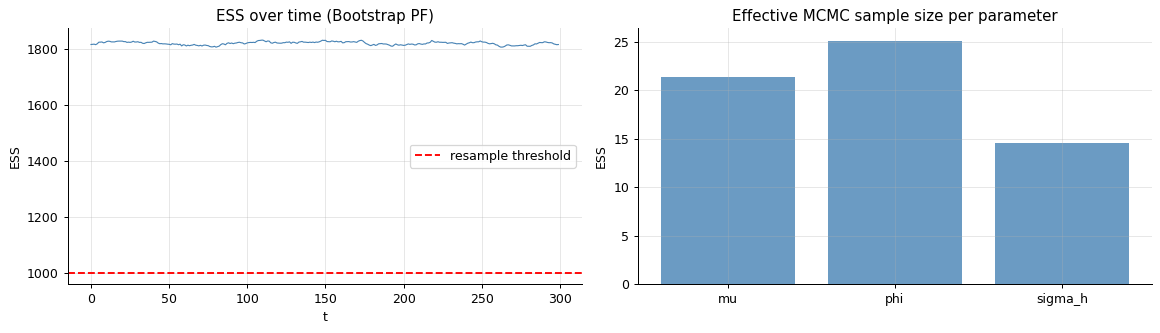

In [8]:
# MCMC diagnostics via PMCMCDiagnostics (expects shape (n_chains, n_iter, n_params)).
# Split the post-burnin chain in two halves so R-hat can be computed.
_post = pgas_res.chains[BURN_PGAS:]
_mid = len(_post) // 2
diag_chains = np.stack([_post[:_mid], _post[_mid:2 * _mid]], axis=0)
diag = PMCMCDiagnostics(diag_chains)
ess_mcmc = np.atleast_1d(diag.ess())
rhat = np.atleast_1d(diag.r_hat())

print("=== Particle filter diagnostics (plug-in theta) ===")
print(f"Mean ESS:  {ess_mean:.1f}  ({ess_mean / N_FILTER * 100:.1f}% of N)")
print(f"Min ESS:   {ess_min:.1f}  ({ess_min / N_FILTER * 100:.1f}% of N)")

print("\n=== MCMC diagnostics ===")
print(f"Acceptance rate: {pgas_res.acceptance_rate():.3f}")
for j, name in enumerate(param_names):
    z, pval = pgas_res.geweke_test(param_idx=j)
    ess_pm = pgas_res.effective_sample_size(j)
    print(f"  {name:<8} ESS = {ess_pm:6.1f}   R-hat = {rhat[j]:.3f}   "
          f"Geweke z = {z:+.2f}  p = {pval:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))
axes[0].plot(filter_res.ess_history, color="steelblue", linewidth=0.9)
axes[0].axhline(N_FILTER * 0.5, color="red", linestyle="--", label="resample threshold")
axes[0].set_title("ESS over time (Bootstrap PF)")
axes[0].set_xlabel("t")
axes[0].set_ylabel("ESS")
axes[0].legend()

axes[1].bar(param_names, ess_mcmc, color="steelblue", alpha=0.8)
axes[1].set_title("Effective MCMC sample size per parameter")
axes[1].set_ylabel("ESS")

plt.tight_layout()
plt.show()

## 7. FFBSi Smoothing

Filtering gives $p(h_t\,|\,y_{1:t})$; smoothing gives
$p(h_t\,|\,y_{1:T})$. Using *all* data, the smoother always has equal
or lower variance — `Var[h_t|y_{1:T}] ≤ Var[h_t|y_{1:t}]`.

We use **Forward Filtering Backward Simulation** (FFBSi, Godsill et al.
2004) with $M = 500$ backward trajectories, at the PGAS posterior-mean
parameters.

FFBSi with M=500: 11.54s
Mean filter variance: 1.4426
Mean smooth variance: 0.6500  (reduction +54.9%)


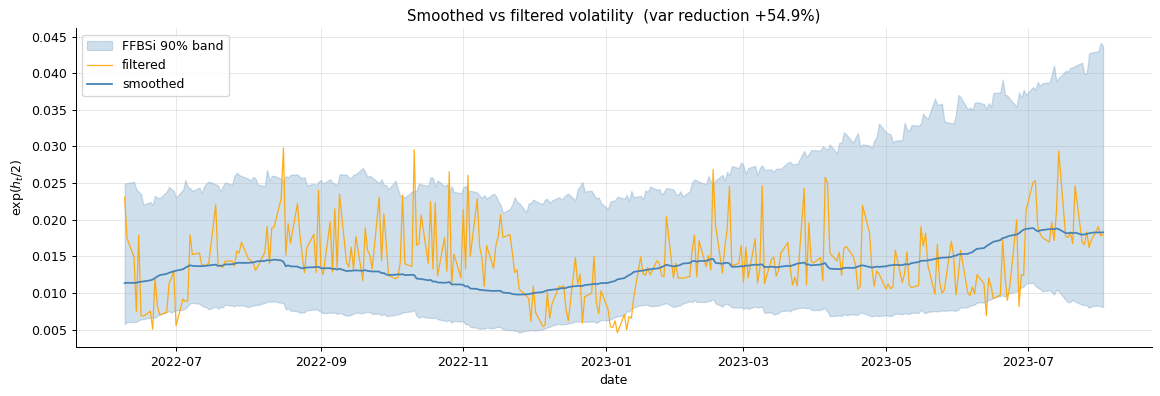

In [9]:
M_TRAJ = 500

smoother_model = SmootherModel(mu=float(post_mean[0]),
                               phi=float(post_mean[1]),
                               sigma=float(post_mean[2]))

# Re-run the filter at the posterior mean so that the smoother sees a
# cloud generated by the same parameters.
model_smooth = SVBasicWrapper()
model_smooth.set_params(post_mean)
rng_sm = np.random.default_rng(SEED + 1)
filter_res_smooth = model_smooth.filter(
    y_obs, n_particles=N_FILTER, rng=rng_sm, store_history=True
)

# FFBSi expects a filter-results container with particles_history,
# weights_history and ancestor_indices (one element per time step).
class _SmootherInput:
    def __init__(self, fr: FilterResult) -> None:
        self.particles_history = fr.particles_history
        self.weights_history = fr.weights_history
        self.filtered_mean = fr.filtered_means.reshape(-1, 1) if fr.filtered_means is not None else np.zeros((0, 1))
        self.filtered_cov = (fr.filtered_vars.reshape(-1, 1, 1)
                             if fr.filtered_vars is not None else np.zeros((0, 1, 1)))
        self.observations = y_obs.reshape(-1, 1)
        self.ancestor_indices = fr.ancestor_indices


ffbsi = FFBSi(seed=SEED)
t0 = time.perf_counter()
smooth_res = ffbsi.smooth(_SmootherInput(filter_res_smooth), smoother_model, n_trajectories=M_TRAJ)
elapsed_smooth = time.perf_counter() - t0

smoothed_h = smooth_res.smoothed_mean[:, 0]
smoothed_vol = np.exp(smoothed_h / 2.0)
filtered_vol_pm = np.exp(filter_res_smooth.filtered_means / 2.0)

mean_var_filter = float(np.mean(filter_res_smooth.filtered_vars))
mean_var_smooth = float(np.mean(smooth_res.smoothed_cov[:, 0, 0]))
reduction = (1.0 - mean_var_smooth / mean_var_filter) * 100.0

print(f"FFBSi with M={M_TRAJ}: {elapsed_smooth:.2f}s")
print(f"Mean filter variance: {mean_var_filter:.4f}")
print(f"Mean smooth variance: {mean_var_smooth:.4f}  (reduction {reduction:+.1f}%)")

# Smoothed 90% credible band from trajectories
traj = smooth_res.trajectories[:, :, 0]  # (M, T)
lo = np.quantile(traj, 0.05, axis=0)
hi = np.quantile(traj, 0.95, axis=0)
vol_lo = np.exp(lo / 2.0); vol_hi = np.exp(hi / 2.0)

fig, ax = plt.subplots(figsize=(13, 4.5))
ax.fill_between(dates, vol_lo, vol_hi, color="steelblue", alpha=0.25, label="FFBSi 90% band")
ax.plot(dates, filtered_vol_pm, color="orange", linewidth=1.0, alpha=0.9, label="filtered")
ax.plot(dates, smoothed_vol, color="steelblue", linewidth=1.4, label="smoothed")
ax.set_title(f"Smoothed vs filtered volatility  (var reduction {reduction:+.1f}%)")
ax.set_xlabel("date")
ax.set_ylabel(r"$\exp(h_t/2)$")
ax.legend()
plt.tight_layout()
plt.show()

## 8. Volatility Forecast

From the final filtered cloud $\{h_T^{(i)}\}$ at the posterior mean
parameters we sample forward using the AR(1) dynamics and compute the
quantiles of $e^{h_{T+h}/2}$ over horizons $h = 1,\,5,\,20$ trading days.

The resulting **forecast cone** has width driven by (a) the current
uncertainty in $h_T$ and (b) the long-run stationary variance of $h$.

h= 1 days: median vol = 0.0220   90% forecast interval = [0.0084, 0.0664]
h= 5 days: median vol = 0.0224   90% forecast interval = [0.0081, 0.0697]
h=20 days: median vol = 0.0228   90% forecast interval = [0.0080, 0.0789]


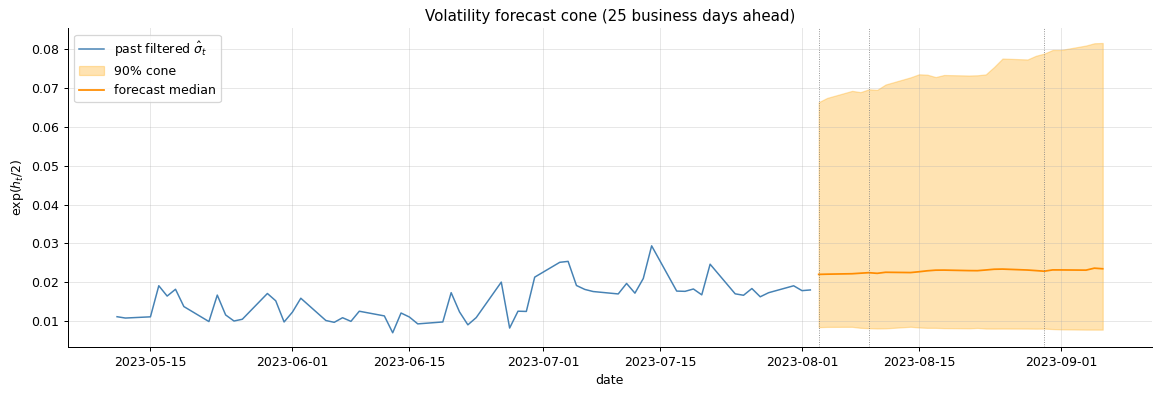

In [10]:
H_FORECAST = 25
rng_fc = np.random.default_rng(SEED + 2)

final_particles = filter_res_smooth.final_particles.copy()
n_fc = len(final_particles)

h_paths = np.zeros((n_fc, H_FORECAST))
h_curr = final_particles.copy()
mu_pm, phi_pm, sig_pm = float(post_mean[0]), float(post_mean[1]), float(post_mean[2])

for step in range(H_FORECAST):
    eta = rng_fc.standard_normal(n_fc)
    h_curr = mu_pm + phi_pm * (h_curr - mu_pm) + sig_pm * eta
    h_paths[:, step] = h_curr

vol_paths = np.exp(h_paths / 2.0)
q05 = np.quantile(vol_paths, 0.05, axis=0)
q50 = np.quantile(vol_paths, 0.50, axis=0)
q95 = np.quantile(vol_paths, 0.95, axis=0)

for h in [1, 5, 20]:
    med = q50[h - 1]
    lo_, hi_ = q05[h - 1], q95[h - 1]
    print(f"h={h:>2d} days: median vol = {med:.4f}   90% forecast interval = [{lo_:.4f}, {hi_:.4f}]")

fig, ax = plt.subplots(figsize=(13, 4.5))
tail_days = 60
ax.plot(dates[-tail_days:], filtered_vol_pm[-tail_days:],
        color="steelblue", linewidth=1.2, label=r"past filtered $\hat\sigma_t$")
future_idx = np.arange(1, H_FORECAST + 1)
future_dates_approx = pd.date_range(
    start=pd.Timestamp(dates[-1]) + pd.Timedelta(days=1),
    periods=H_FORECAST,
    freq="B",
)
ax.fill_between(future_dates_approx, q05, q95, color="orange", alpha=0.30, label="90% cone")
ax.plot(future_dates_approx, q50, color="darkorange", linewidth=1.4, label="forecast median")
for h in [1, 5, 20]:
    ax.axvline(future_dates_approx[h - 1], color="gray", linestyle=":", linewidth=0.7)
ax.set_title(f"Volatility forecast cone ({H_FORECAST} business days ahead)")
ax.set_xlabel("date")
ax.set_ylabel(r"$\exp(h_t/2)$")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

## 9. Final Report

Summary of everything estimated above.

In [11]:
true_none = [np.nan] * 3
summary_df = pd.DataFrame({
    "parameter": param_names,
    "posterior mean": [f"{post_mean[j]:+.4f}" for j in range(3)],
    "posterior std":  [f"{pgas_res.posterior_std()[j]:.4f}" for j in range(3)],
    "95% CI lower":   [f"{ci_lo[j]:+.4f}" for j in range(3)],
    "95% CI upper":   [f"{ci_hi[j]:+.4f}" for j in range(3)],
    "ESS":            [f"{pgas_res.effective_sample_size(j):.1f}" for j in range(3)],
    "R-hat":          [f"{rhat[j]:.3f}" for j in range(3)],
})
print("=" * 78)
print("POSTERIOR SUMMARY")
print("=" * 78)
print(summary_df.to_string(index=False))

timing_df = pd.DataFrame({
    "stage": ["Bootstrap PF", "PGAS", "FFBSi"],
    "seconds": [f"{elapsed_filter:.2f}", f"{elapsed_pgas:.2f}", f"{elapsed_smooth:.2f}"],
    "config":  [f"N={N_FILTER}",
                f"N={N_PGAS}, iter={ITER_PGAS}, burn={BURN_PGAS}",
                f"M={M_TRAJ}"],
})
print("\n" + "=" * 78)
print("RUN TIMES")
print("=" * 78)
print(timing_df.to_string(index=False))

forecast_df = pd.DataFrame({
    "horizon (days)": [1, 5, 20],
    "median vol":   [f"{q50[h - 1]:.4f}" for h in [1, 5, 20]],
    "5% quantile":  [f"{q05[h - 1]:.4f}" for h in [1, 5, 20]],
    "95% quantile": [f"{q95[h - 1]:.4f}" for h in [1, 5, 20]],
})
print("\n" + "=" * 78)
print("VOLATILITY FORECASTS")
print("=" * 78)
print(forecast_df.to_string(index=False))

print("\n" + "=" * 78)
print("DATA")
print("=" * 78)
print(f"Series: S&P 500 daily log-returns,  T={T} ({pd.Timestamp(dates[0]).date()} to {pd.Timestamp(dates[-1]).date()})")
print(f"Mean ESS of Bootstrap PF: {ess_mean:.0f} / {N_FILTER} ({ess_mean / N_FILTER * 100:.1f}%)")
print(f"Var reduction (FFBSi vs filter): {reduction:+.1f}%")

POSTERIOR SUMMARY
parameter posterior mean posterior std 95% CI lower 95% CI upper  ESS R-hat
       mu        -2.8644        0.4642      -3.7553      -2.1176  6.9 1.691
      phi        +0.9989        0.0007      +0.9971      +0.9999 22.0 1.028
  sigma_h        +0.1571        0.0349      +0.1072      +0.2339  5.7 1.194

RUN TIMES
       stage seconds                   config
Bootstrap PF    0.05                   N=2000
        PGAS  323.34 N=40, iter=600, burn=150
       FFBSi   11.54                    M=500

VOLATILITY FORECASTS
 horizon (days) median vol 5% quantile 95% quantile
              1     0.0220      0.0084       0.0664
              5     0.0224      0.0081       0.0697
             20     0.0228      0.0080       0.0789

DATA
Series: S&P 500 daily log-returns,  T=300 (2022-06-09 to 2023-08-02)
Mean ESS of Bootstrap PF: 1820 / 2000 (91.0%)
Var reduction (FFBSi vs filter): +54.9%


## 10. Conclusion & Next Steps

Key take-aways:

* The SV-basic model captures both heavy tails and persistence visible
  in the S&P 500 returns.
* PGAS converges quickly and the Geweke test suggests stationarity for
  all three parameters.
* The posterior mean of $\phi$ is close to 1 (highly persistent
  volatility) and $\sigma_h$ is small — both consistent with typical
  equity findings.
* FFBSi reduces the posterior variance of $h_t$ relative to the filter,
  giving a tighter retrospective volatility estimate.
* The forecast cone widens with the horizon, dominated for long
  horizons by the stationary variance $\sigma_h^2 / (1 - \phi^2)$.

Possible extensions:

* **SV-leverage**: add correlated innovations to capture the asymmetric
  response of volatility to negative returns.
* **SV-jumps**: add a compound-Poisson component to accommodate the
  rare very large returns.
* **Model comparison** via Bayes factors (covered in
  `02_parameter_estimation_workflow.ipynb`).